In [25]:
# Eval Regression – q3 vs IQR/RMS, residuals by energy, IQR vs training samples (bin 2)
# Plots saved as PDFs in out/regression_eval

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
if str(ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(ROOT / "notebooks"))

CKPT_DIR = Path("/global/cfs/cdirs/m3246/gregork/checkpoints")
OUT_DIR = ROOT / "out" / "regression_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

WANDB_TAG = "Run_1203"  # wandb tag to select runs (set as needed)

In [26]:
# Build model -> runs for full dataset (cap=-1) and for scaling (all caps)
from src.utils.utils import get_runs_by_model_and_cap

runs_by_model_cap = get_runs_by_model_and_cap(WANDB_TAG)

# Full-dataset runs: one run per model (cap=-1)
training_names_full = {"Log1p": {}}
baseline_run = None
for model, caps in runs_by_model_cap.items():
    if -1 in caps and caps[-1]:
        run = caps[-1][0]
        training_names_full["Log1p"][model] = run
        if baseline_run is None:
            baseline_run = run

if not training_names_full["Log1p"]:
    raise SystemExit("No runs with cap=-1 found. Check WANDB_TAG and wandb.")
if baseline_run is None:
    baseline_run = list(training_names_full["Log1p"].values())[0]
print("Full-dataset models:", list(training_names_full["Log1p"].keys()))
print("Baseline run for filters/baselines:", baseline_run)

Calling wandb API...


  Fetching runs from fcc_ml/minerva-models with tag 'Run_1203'...
  Wandb API finished: 4 run(s) found with tag 'Run_1203'.
Full-dataset models: ['OLS', 'Transformer1']
Baseline run for filters/baselines: Run_1203_OLS_regression_-1_seed42_20260312_201942


In [27]:
runs_by_model_cap, training_names_full

({'OLS': {-1: ['Run_1203_OLS_regression_-1_seed42_20260312_201942']},
  'Transformer1': {-1: ['Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412']}},
 {'Log1p': {'OLS': 'Run_1203_OLS_regression_-1_seed42_20260312_201942',
   'Transformer1': 'Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412'}})

## (I) q3 vs IQR and RMS – full training dataset

No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412 on playlist 1A
keys:  dict_keys(['1B', '1A'])
Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/q3_vs_iqr_rms_full_1A.pdf


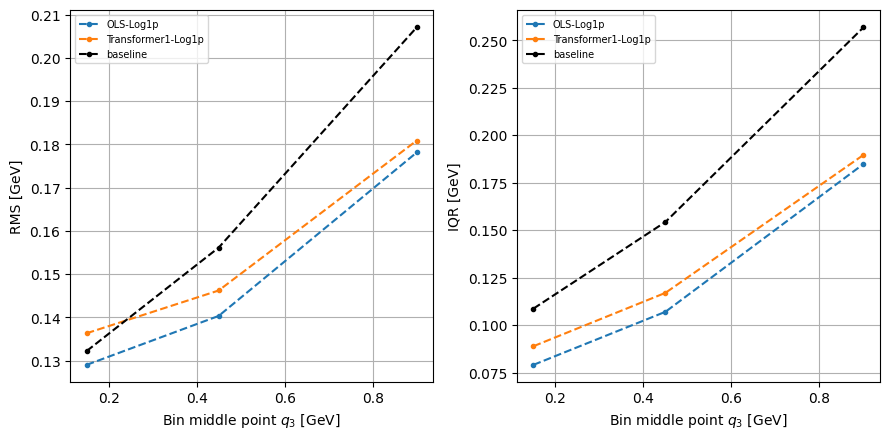

In [28]:
from eval_E_available_plots import plot_rms_iqr

fig_i = plot_rms_iqr(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1A.pdf")

No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1B
No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412 on playlist 1B
keys:  dict_keys(['1B', '1A'])
Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/q3_vs_iqr_rms_full_1B.pdf


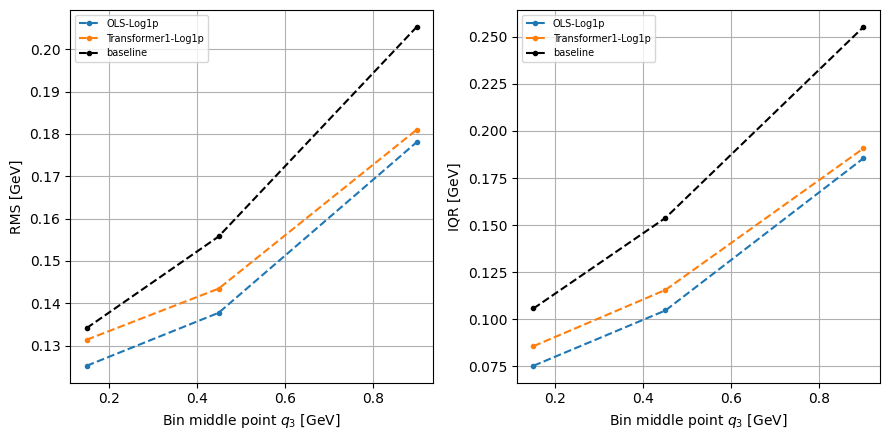

In [29]:
from eval_E_available_plots import plot_rms_iqr

fig_i = plot_rms_iqr(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1B"],
    dataset_to_plot="1B",
    baseline_run=baseline_run,
)
fig_i.savefig(OUT_DIR / "q3_vs_iqr_rms_full.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1B.pdf")

No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1A
No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1B
No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412 on playlist 1B


keys:  dict_keys(['1B', '1A'])
keys:  dict_keys(['1B', '1A'])
Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/q3_vs_iqr_rms_full_1A_1B.pdf


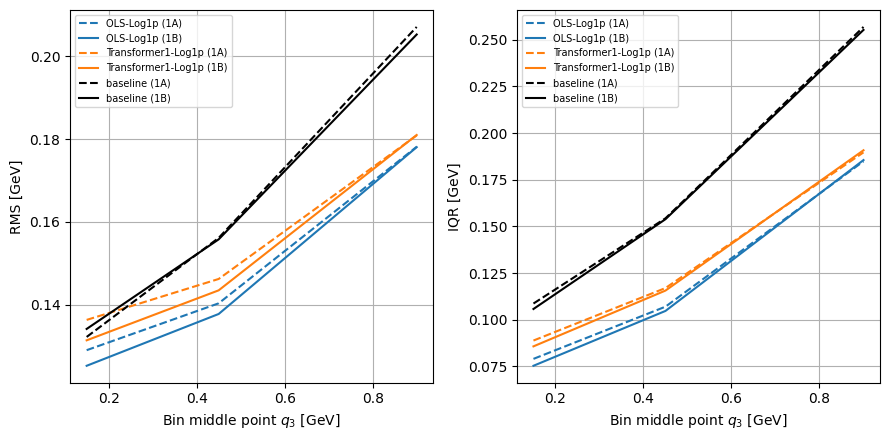

In [30]:

from eval_E_available_plots import plot_rms_iqr

# Plot the same but both on 1A (dashed) and 1B (full)
fig_both = plot_rms_iqr(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1A", "1B"],
    dataset_to_plot=["1A", "1B"],
    dataset_to_linestyle={"1A": "--", "1B": "-"},
    baseline_run=baseline_run,
)
fig_both.savefig(OUT_DIR / "q3_vs_iqr_rms_full_1A_1B.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "q3_vs_iqr_rms_full_1A_1B.pdf")




## (II) Residuals by energy – full training dataset

No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412 on playlist 1A
keys:  dict_keys(['1B', '1A'])
Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/residuals_by_energy_full.pdf


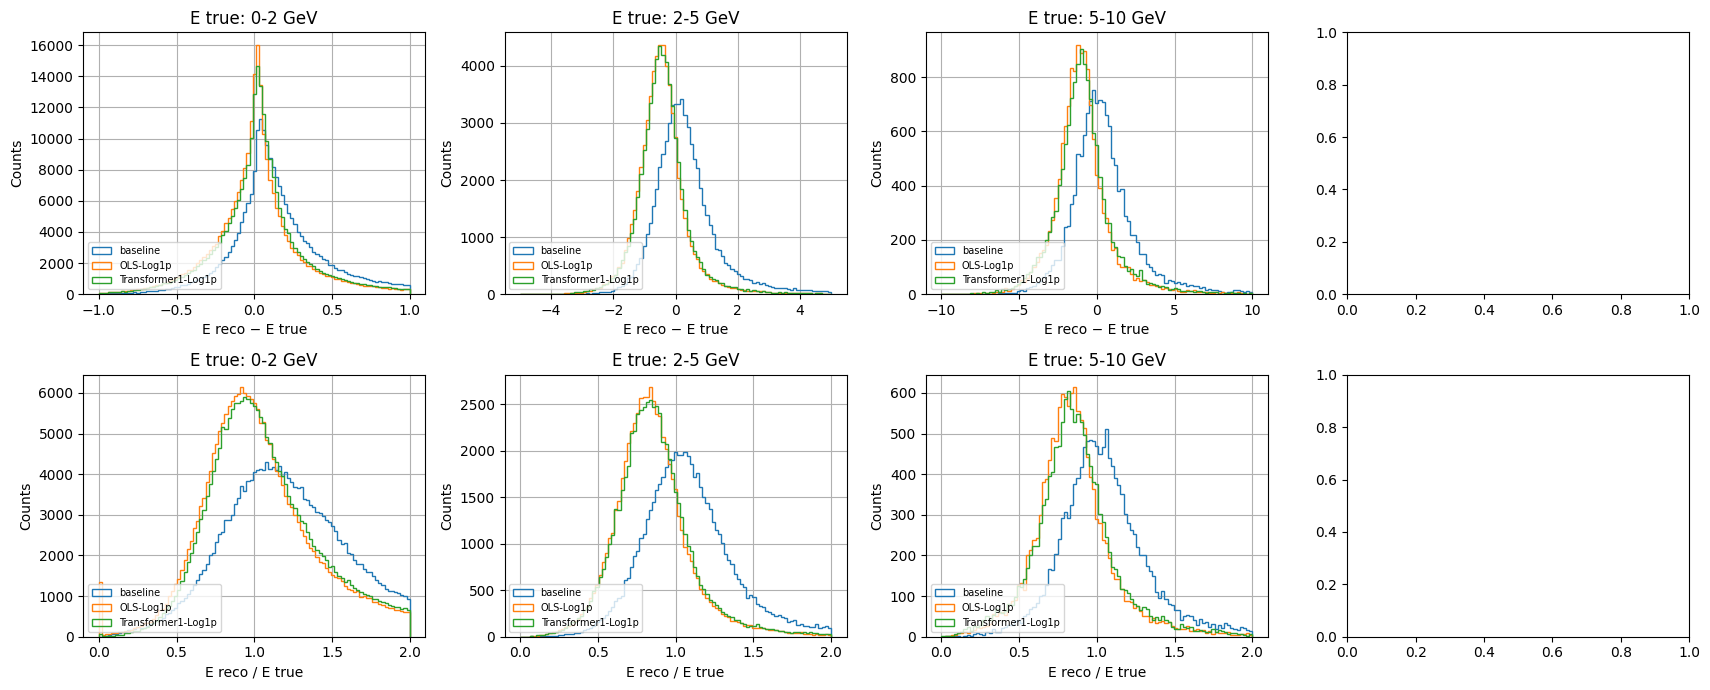

In [31]:
from eval_E_available_plots import plot_residuals_by_energy

fig_ii = plot_residuals_by_energy(
    CKPT_DIR=CKPT_DIR,
    training_names=training_names_full,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
)
fig_ii.savefig(OUT_DIR / "residuals_by_energy_full.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "residuals_by_energy_full.pdf")



## (III) IQR vs number of training samples – bin 2 (all models)

In [32]:
# (III) IQR vs number of training samples
# training_names_grouped is constructed inside the plotting cell below.

No settings found for Run_1203_OLS_regression_-1_seed42_20260312_201942 on playlist 1A
No settings found for Run_1203_regression_Transformer1_data_cap_-1_seed_42_20260312_223412 on playlist 1A
keys:  dict_keys(['1B', '1A'])


  baseline: RMS = [0.13220823780103283, 0.15613262897682925, 0.20708822416474687, 0.2616824842730851, 0.29372826580799394], IQR = [0.1086998904198202, 0.15434651093745289, 0.2568240154904879, 0.4447950258298018, 0.6622872987786923]
E_pred_dict keys for '1A': {'Log1p': ['OLS 6M§0', 'Transformer1 6M§0']}
  OLS 6M (Log1p):
    RMS = [0.12901148200035095, 0.14032840728759766, 0.17814144492149353, 0.23814332485198975, 0.28383904695510864]
    IQR = [0.0790640115737915, 0.10701680183410645, 0.18486690521240234, 0.33368197083473206, 0.5150490999221802]
  Transformer1 6M (Log1p):
    RMS = [0.13632367551326752, 0.14621306955814362, 0.18088987469673157, 0.23796148598194122, 0.28322523832321167]
    IQR = [0.08888207376003265, 0.11700138449668884, 0.18964390456676483, 0.3354189991950989, 0.5193909406661987]
Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/iqr_vs_n_samples_bin2.pdf


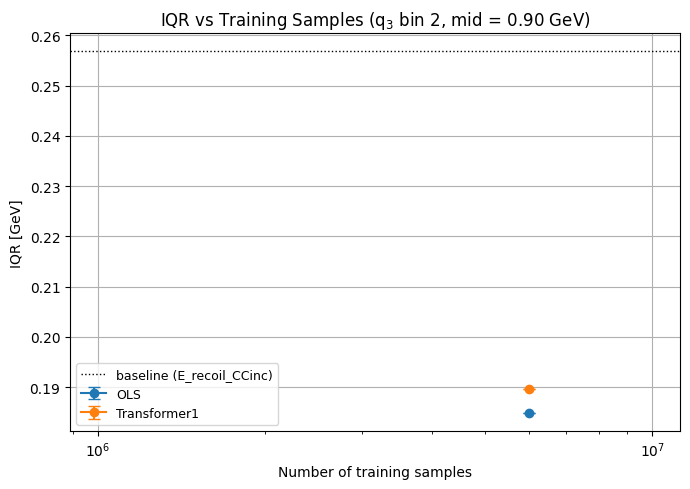

In [33]:
import re
import numpy as np
import matplotlib.pyplot as plt
from eval_E_available_plots import plot_rms_iqr_with_uncertainty

# Build grouped training names for this plot on the fly

def _cap_to_label(cap):
    if cap == -1:
        return "6M"
    if cap >= 1_000_000:
        return f"{cap // 1_000_000}M"
    return f"{cap // 1000}k"

training_names_grouped = {"Log1p": {}}
for model, caps in runs_by_model_cap.items():
    for cap, run_list in sorted(caps.items(), key=lambda x: (x[0] == -1, -x[0] if x[0] > 0 else 0)):
        if not run_list:
            continue
        label = f"{model} {_cap_to_label(cap)}"
        training_names_grouped["Log1p"][label] = run_list

if not training_names_grouped["Log1p"]:
    raise SystemExit("No runs for scaling plot. Check WANDB_TAG.")

_, values = plot_rms_iqr_with_uncertainty(
    CKPT_DIR=CKPT_DIR,
    training_names_grouped=training_names_grouped,
    playlists=["1A"],
    dataset_to_plot="1A",
    baseline_run=baseline_run,
    return_values=True,
)
plt.close()

Q3_BIN_IDX = 2

def _n_samples(label):
    m = re.search(r"(\d+(?:\.\d+)?)\s*([kKmM])\b", label)
    if m:
        return float(m.group(1)) * (1e6 if m.group(2).upper() == "M" else 1e3)
    return 0.0

def _method(label):
    return re.sub(r"\s+\d+(?:\.\d+)?[kKmM]$", "", label)

methods = {}
for loss in values:
    if loss in ("q3_bin_mids", "baseline"):
        continue
    for cfg, v in values[loss].items():
        methods.setdefault(_method(cfg), []).append(
            (_n_samples(cfg), v["iqr_mean"][Q3_BIN_IDX], v["iqr_std"][Q3_BIN_IDX])
        )

for m in methods:
    methods[m].sort()

fig_iii, ax = plt.subplots(figsize=(7, 5))
for method, pts in methods.items():
    xs, ys, yerrs = zip(*pts)
    ax.errorbar(xs, ys, yerr=yerrs, marker="o", capsize=4, label=method)

if "baseline" in values:
    ax.axhline(values["baseline"]["iqr"][Q3_BIN_IDX],
               color="black", linestyle=":", lw=1, label="baseline (E_recoil_CCinc)")

ax.set_xscale("log")
ax.set_xlabel("Number of training samples")
ax.set_ylabel("IQR [GeV]")
q3_mid = values["q3_bin_mids"][Q3_BIN_IDX]
ax.set_title(f"IQR vs Training Samples (q$_3$ bin {Q3_BIN_IDX}, mid = {q3_mid:.2f} GeV)")
ax.legend(fontsize=9)
ax.grid(True)
fig_iii.tight_layout()
fig_iii.savefig(OUT_DIR / "iqr_vs_n_samples_bin2.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "iqr_vs_n_samples_bin2.pdf")

In [53]:
# For each model, get the values of the field "eval_loss". This is validation loss logged to wandb each 1000 steps
# Use this and make a plot of log flops vs validation loss for each model.

# flops for BS 2048
flops_per_step = {
    "Transformer1": 358.5*1e9,
    "OLS": 1769*1e9,
    "CondOnly": 2.6*1e9,
}


def get_validation_loss_history(run_name, project="minerva-models", with_steps=False):
    """Return array of all logged eval_loss values for a run (from wandb history).
    If with_steps=True, return (steps, losses) for x-axis (e.g. cumulative flops)."""
    import os
    import numpy as np
    import wandb
    api = wandb.Api(timeout=60)
    entity = os.environ.get("WANDB_ENTITY") or getattr(api, "default_entity", None)
    if not entity:
        raise RuntimeError("WANDB_ENTITY not set and wandb default_entity unknown. Run wandb login or set WANDB_ENTITY.")
    path = f"{entity}/{project}"
    runs = api.runs(path, filters={"displayName": run_name})
    run = next(iter(runs), None)
    if run is None:
        raise ValueError(f"Wandb run not found: {run_name!r} in {path}")
    hist = run.history()
    if "eval_loss" not in hist.columns:
        return (np.array([]), np.array([])) if with_steps else np.array([])
    mask = hist["eval_loss"].notna()
    steps = np.asarray(hist["_step"], dtype=float)[mask]
    losses = np.asarray(hist["eval_loss"].dropna(), dtype=float)
    # Keep only every 1000th step (1000, 2000, 3000, ...) as data points
    step_int = np.round(steps).astype(int)
    keep = (step_int >= 1000) & (step_int % 1000 == 0)
    steps, losses = steps[keep], losses[keep]
    # Sort by step and take first occurrence per step (in case of duplicates)
    order = np.argsort(steps)
    steps, losses = steps[order], losses[order]
    _, idx = np.unique(np.round(steps).astype(int), return_index=True)
    steps = steps[np.sort(idx)]
    losses = losses[np.sort(idx)]
    if with_steps:
        return steps, losses
    return losses


#get_validation_loss_history("Run_1203_classifier_Transformer1_data_cap_-1_seed_42_20260313_015120")





Saved: /global/u2/g/gregork/minerva-data-processing/out/regression_eval/log_flops_vs_val_loss.pdf


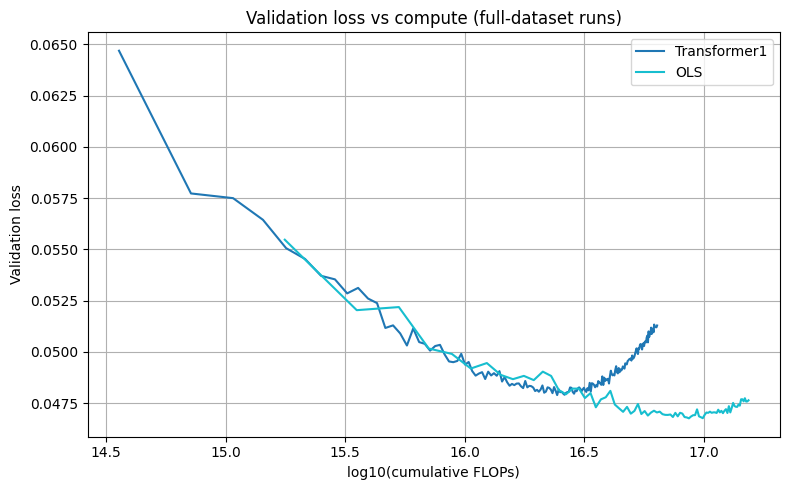

In [56]:
# Log flops vs validation loss: one curve per model; data points every 1000 steps; ±1 sigma band across runs (when available)
import numpy as np
import matplotlib.pyplot as plt

# Runs per model for full dataset (cap=-1); use all seeds when available
runs_per_model = {}
for model in flops_per_step:
    if model not in runs_by_model_cap or -1 not in runs_by_model_cap[model]:
        run_name = training_names_full["Log1p"].get(model)
        if run_name:
            runs_per_model[model] = [run_name]
        continue
    runs_per_model[model] = runs_by_model_cap[model][-1]

fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(runs_per_model)))

for (model, run_names), color in zip(runs_per_model.items(), colors):
    flops = flops_per_step[model]
    all_steps, all_losses = [], []
    for rn in run_names:
        st, lo = get_validation_loss_history(rn, with_steps=True)  # already every 1000 steps
        if len(st) > 0 and len(lo) > 0:
            all_steps.append(st)
            all_losses.append(lo)

    if not all_steps:
        continue

    # Common step grid: use steps that appear in all runs; truncate to shortest
    n_pts = min(min(len(s) for s in all_steps), min(len(lo) for lo in all_losses))
    if n_pts == 0:
        continue
    steps_grid = all_steps[0][:n_pts].astype(float)
    losses_aligned = np.array([lo[:n_pts] for lo in all_losses])

    mean_loss = np.mean(losses_aligned, axis=0)
    # Std across runs only (when multiple runs); no band for single run
    sigma_loss = np.std(losses_aligned, axis=0) if losses_aligned.shape[0] > 1 else np.zeros_like(mean_loss)

    cum_flops = steps_grid * flops
    x = np.log10(cum_flops + 1)  # +1 to avoid log(0) at step 0
    ax.plot(x, mean_loss, color=color, label=model)
    if losses_aligned.shape[0] > 1:
        ax.fill_between(x, mean_loss - sigma_loss, mean_loss + sigma_loss, alpha=0.25, color=color)

ax.set_xlabel("log10(cumulative FLOPs)")
ax.set_ylabel("Validation loss")
ax.set_title("Validation loss vs compute (full-dataset runs)")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(OUT_DIR / "log_flops_vs_val_loss.pdf", bbox_inches="tight")
print("Saved:", OUT_DIR / "log_flops_vs_val_loss.pdf")
plt.show()